Профессия Data Science  
Блок 6. Математика в ML. Часть II  
**MATH&ML-11. Кластеризация и техники понижения размерности. Часть II**

---

## **✍ Оглавление:**
1. Введение
2. Оценка качества кластеризации: внутренние меры
3. Оценка качества кластеризации: внешние меры

## **1. Введение**

Выделяют две больших группы методов, с помощью которых можно оценить результат кластеризации:

**Внутренние меры** — это метрики, которые оценивают качество кластеризации только по той информации, которая есть в неразмеченных данных.

**Внешние меры** — это метрики, которые используют, если в данных есть информация о некотором заранее известном разделении на кластеры, с которым можно сравнить полученный результат.

## **2. Оценка качества кластеризации: внутренние меры**

В библиотеке sklearn реализованы три наиболее популярные метрики:

- коэффициент силуэта (Silhouette Coefficient);
- индекс Калински — Харабаса (Calinski-Harabasz Index);
- индекс Дэвиса — Болдина (Davies-Bouldin Index).

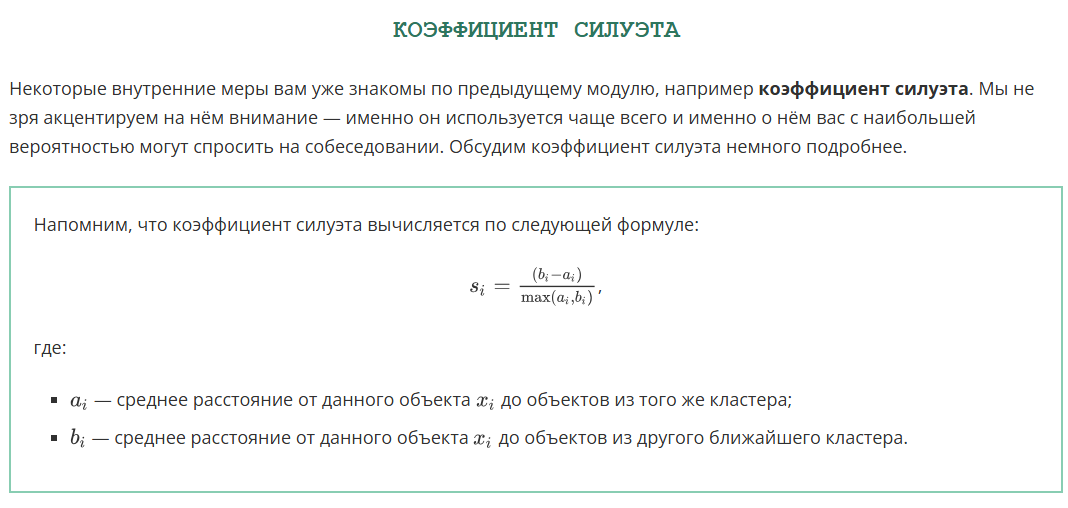

Для вычисления коэффициента силуэта в библиотеке sklearn используется silhouette_score:

In [ ]:
#определяем алгоритм кластеризации
km = KMeans(n_clusters=3, random_state=42)
#обучаем его на наших данных
km.fit_predict(X)
#вычисляем значение коэффициента силуэта
score = silhouette_score(X, km.labels_, metric='euclidean')

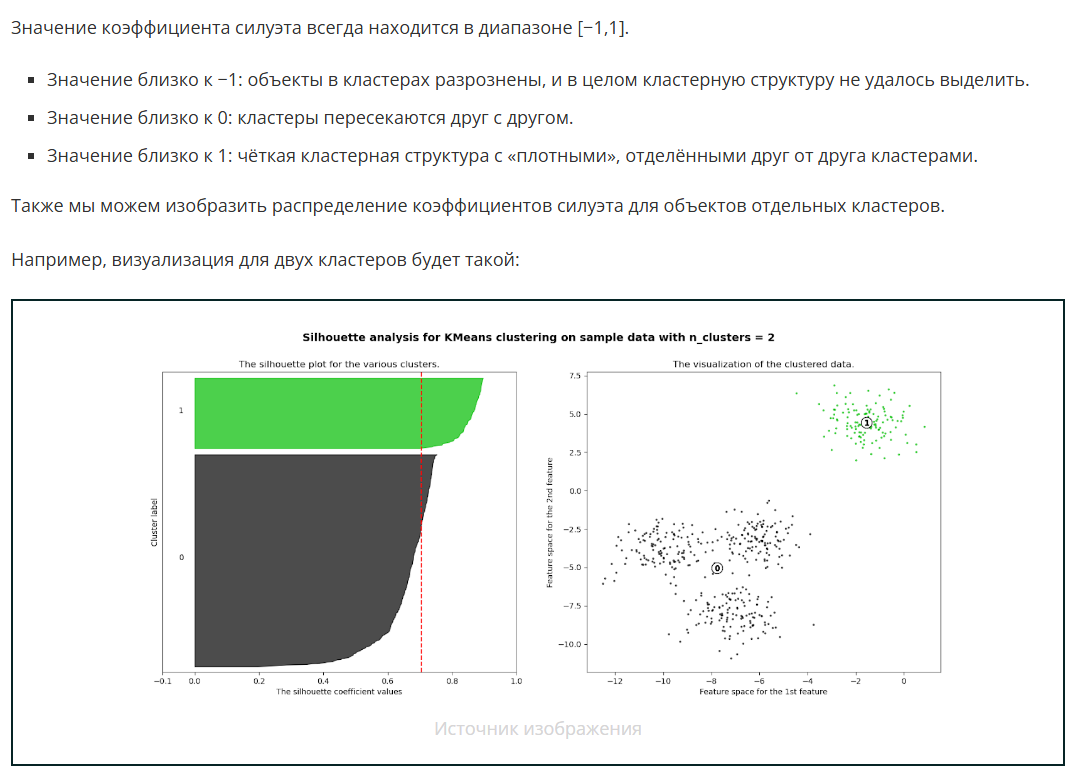

Пояснение. На графике слева красной пунктирной линией здесь и далее отмечено среднее значение коэффициента силуэта для данного случая кластеризации. Разными цветами (серый и зелёный) визуализированы распределения значений коэффициентов силуэта для объектов соответствующих кластеров. На графике справа отмечены объекты, окрашенные в разные цвета в соответствии с их принадлежностью к кластерам.

Здесь мы видим, что «нулевой» кластер (серого цвета) включает в себя точки с более маленькими значениями. Это довольно хорошо соотносится с правой визуализацией, т. к. в сером кластере точки местами разрознены сильнее, чем в зелёном.

Для случая трёх кластеров ситуация будет следующей:

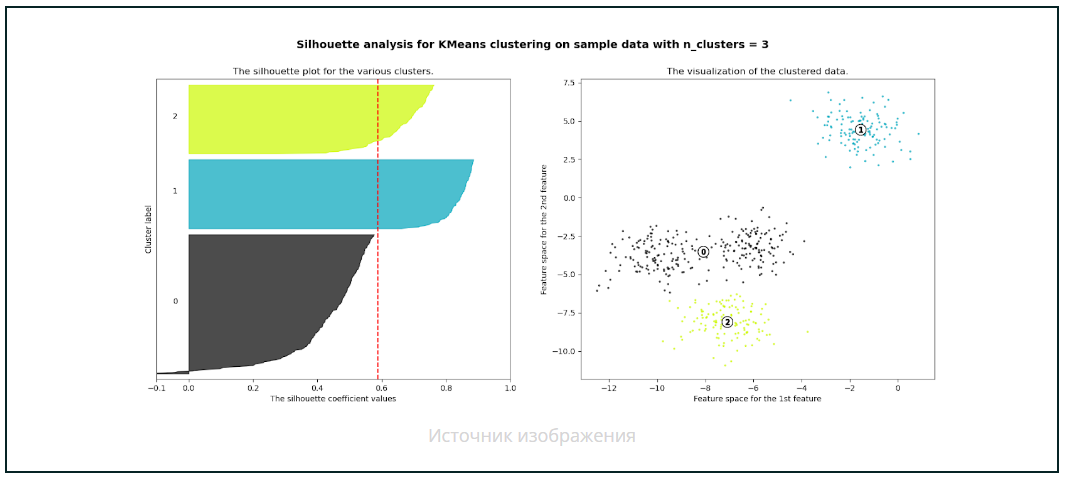

Довольно естественно (если посмотреть на график справа), что голубой кластер показывает наилучшую согласованность. У точек серого кластера коэффициенты всё так же самые низкие — явно напрашивается его разделение на ещё два кластера, и это действительно улучшает качество, так как значения коэффициентов силуэта увеличились (в новых сером и жёлтом кластерах они выше, чем были в предыдущем сером):

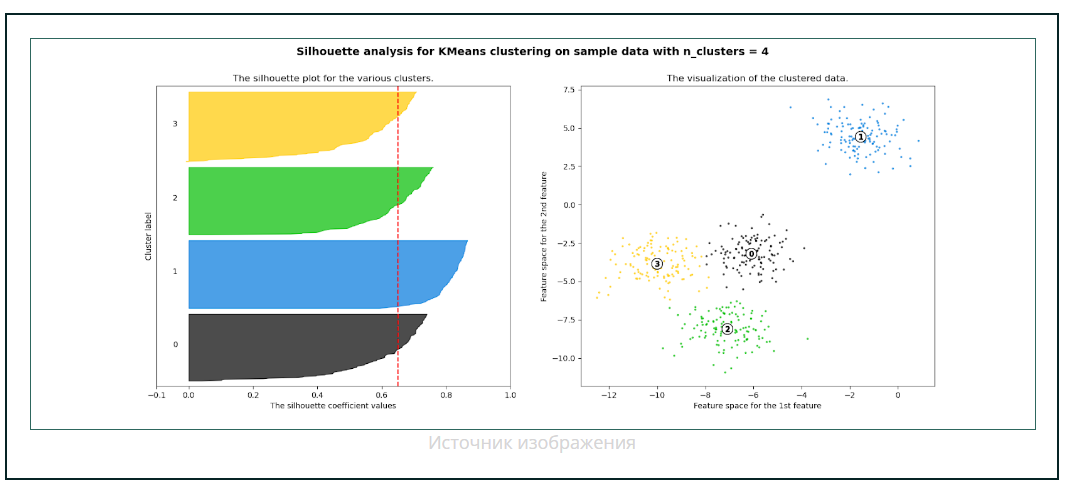

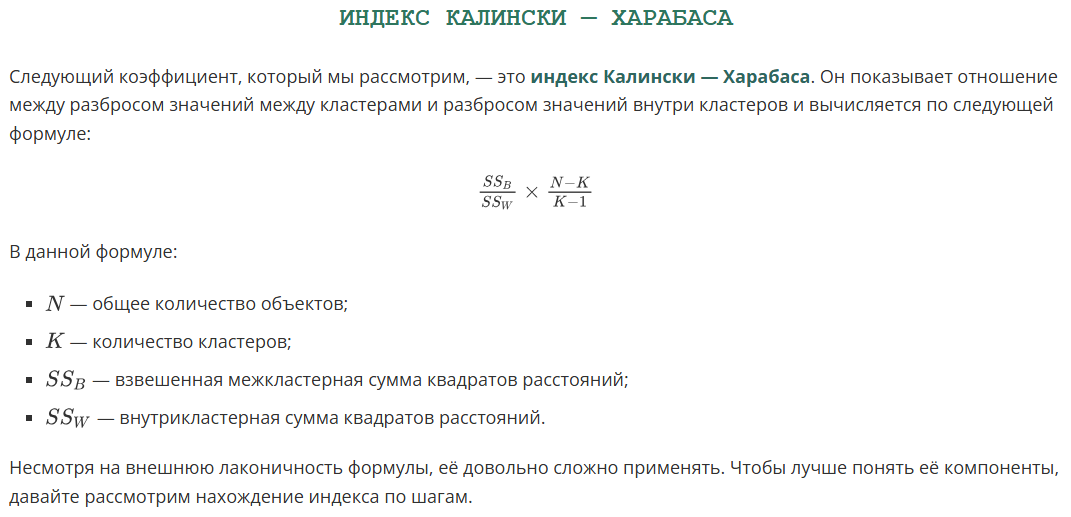

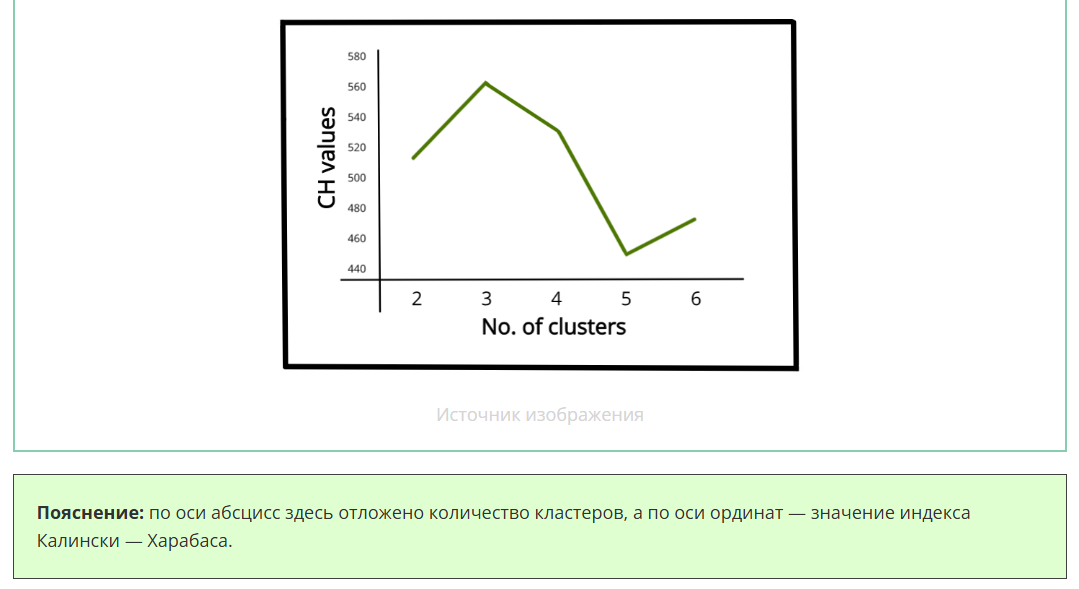

В библиотеке sklearn данный алгоритм реализуется с помощью метода calinski_harabasz_score():

In [ ]:
#определяем алгоритм кластеризации
km = KMeans(n_clusters=3, random_state=42)
#обучаем его на наших данных
km.fit_predict(X)
#вычисляем значение коэффициента Калински — Харабаса
score = calinski_harabasz_score(X, km.labels_)

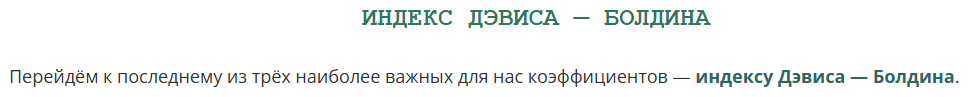

Давайте разберёмся, как интерпретировать значение коэффициента Дэвиса — Болдина. Индекс показывает среднюю «схожесть» между кластерами, и 0 — это минимально возможное значение. Разумеется, так как мы хотим, чтобы кластеры были максимально различными (т. е. имели низкую схожесть), мы должны пытаться достичь как можно более маленького значения.

В библиотеке sklearn индекс Дэвиса — Болдина реализуется с помощью метода davies_bouldin_score():

In [ ]:
#определяем алгоритм кластеризации
km = KMeans(n_clusters=3, random_state=42)
#обучаем его на наших данных
km.fit_predict(X)
#вычисляем значение коэффициента Дэвиса — Болдина
score = davies_bouldin_score(X, km.labels_)

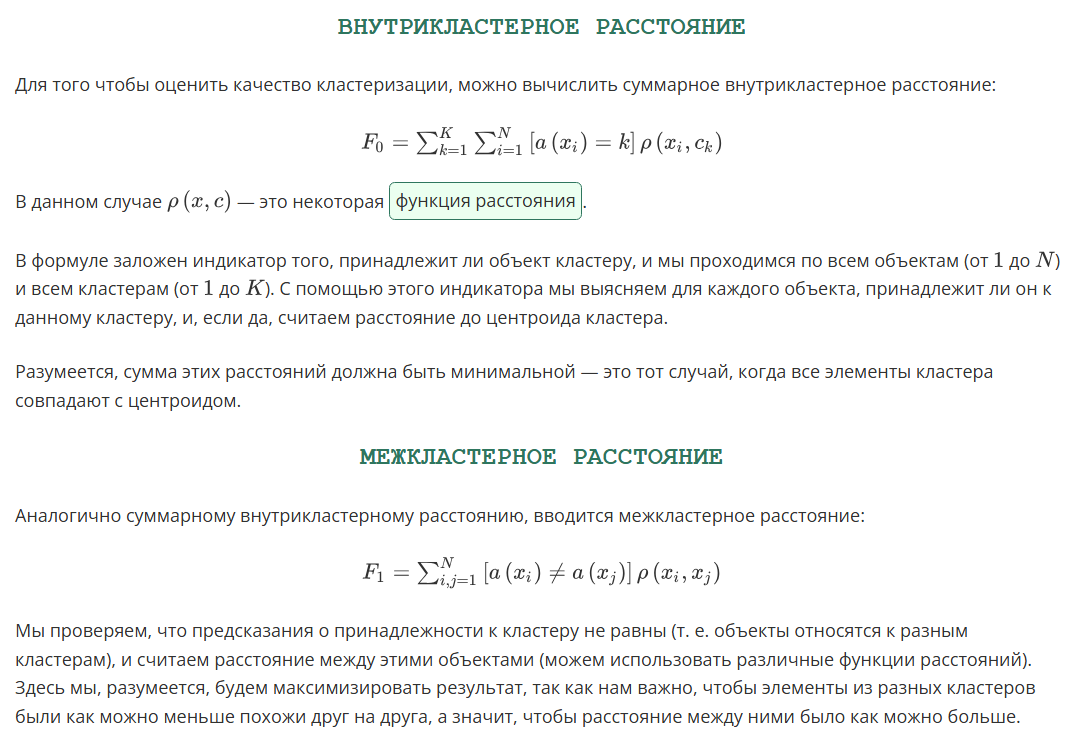

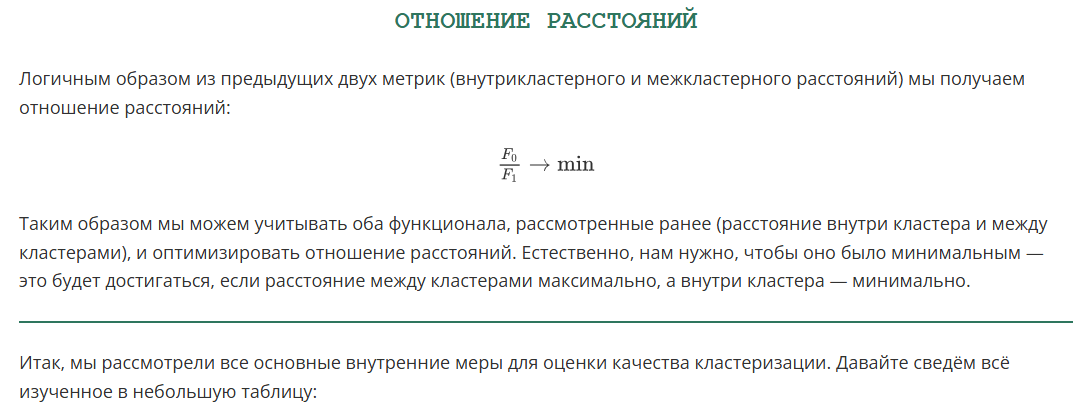

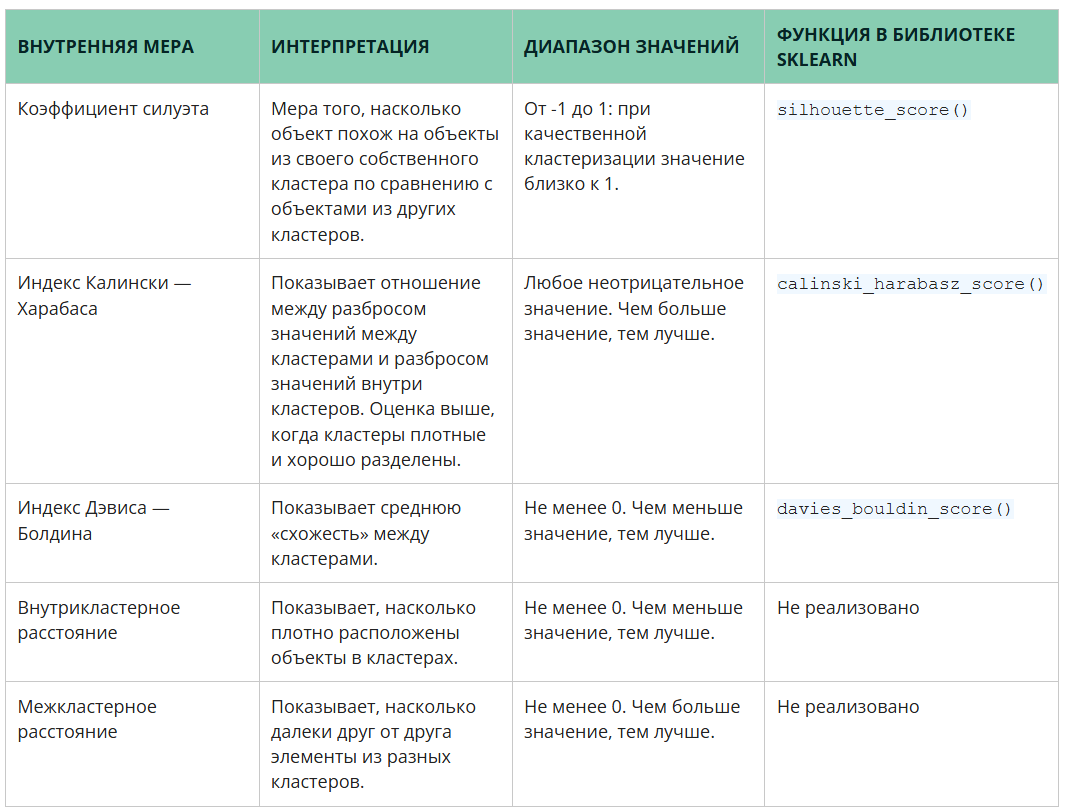

## **3. Оценка качества кластеризации: внешние меры**

